In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score



In [2]:
df = pd.read_csv("smart_irrigation_system.csv")
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [3]:
df.isnull().sum()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  object 
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  object 
 11  Crop_Growth_Stage        10000 non-null  object 
 12  Season                   10000 non-null  object 
 13  Irrigation_Type          10000 non-null  object 
 14  Water_Source           

In [4]:
df.shape

(10000, 20)

In [5]:
print(df["Irrigation_Need"].value_counts())

Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64


In [6]:
le = LabelEncoder()
df['Soil_Type'] = le.fit_transform(df['Soil_Type'])
df['Crop_Type'] = le.fit_transform(df['Crop_Type'])
df['Crop_Growth_Stage'] = le.fit_transform(df['Crop_Growth_Stage'])
df['Season'] = le.fit_transform(df['Season'])
df['Irrigation_Type'] = le.fit_transform(df['Irrigation_Type'])
df['Water_Source'] = le.fit_transform(df['Water_Source'])
df['Region'] = le.fit_transform(df['Region'])
df['Mulching_Used'] = le.fit_transform(df['Mulching_Used'])

In [7]:
df

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,5,3,1,2,2,4.73,1,1.98,3,Low
1,3,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,1,0,2,0,0,12.22,1,33.56,0,Medium
2,2,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,0,1,1,1,2,5.52,1,34.62,3,Low
3,0,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,5,2,0,0,2,1.43,1,84.03,2,Medium
4,0,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,0,2,2,0,3,2.52,0,60.86,3,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,7.01,26.67,0.86,0.76,27.61,52.20,1075.12,7.41,19.66,4,2,0,1,0,2.62,1,92.44,3,Low
9996,0,5.40,49.44,0.90,1.19,34.03,52.31,1591.84,9.86,5.66,1,2,0,2,0,4.87,0,15.46,3,Low
9997,1,4.97,60.63,0.99,1.30,36.68,68.16,2384.87,10.75,13.40,2,1,0,0,0,10.08,1,116.36,2,Low
9998,1,7.12,44.33,1.56,1.08,31.50,64.83,2397.01,4.03,3.05,4,1,0,2,2,11.11,1,118.17,1,Low


In [8]:
X = df.drop("Irrigation_Need", axis=1)
y = df["Irrigation_Need"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred, average='macro')
print("Precision:", precision)

recall = recall_score(y_test, y_pred, average='macro')
print("Recall:", recall)

f1 = f1_score(y_test, y_pred, average='macro')
print("F1 Score:", f1)
con_matrix = confusion_matrix(y_test, y_pred)
print("confusion_matrix:", con_matrix)



Accuracy: 0.9895
Precision: 0.9909043422631886
Recall: 0.9026719534414602
F1 Score: 0.9386516727581445
confusion_matrix: [[  42    0   17]
 [   0 1201    3]
 [   0    1  736]]


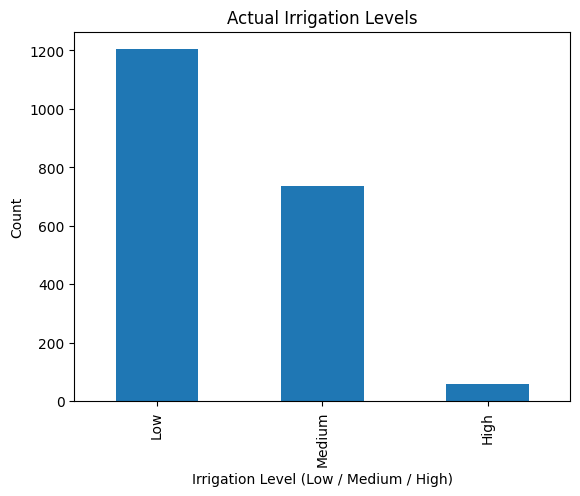

In [12]:
actual = y_test.value_counts()

plt.figure()
actual.plot(kind='bar')
plt.title("Actual Irrigation Levels")
plt.xlabel("Irrigation Level (Low / Medium / High)")
plt.ylabel("Count")
plt.show()

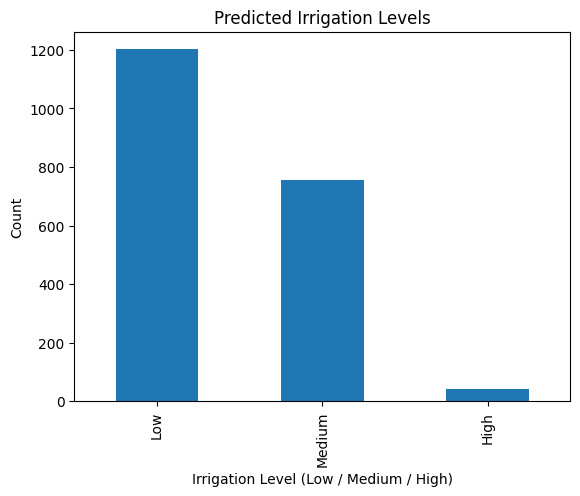

In [13]:
predicted = pd.Series(y_pred).value_counts()

plt.figure()
predicted.plot(kind='bar')
plt.title("Predicted Irrigation Levels")
plt.xlabel("Irrigation Level (Low / Medium / High)")
plt.ylabel("Count")
plt.show()

In [ ]:
sample_data = pd.DataFrame({
    'Soil_Type':[1],
    'Soil_pH':[6.8],
    'Soil_Moisture':[35],
    'Organic_Carbon':[1.2],
    'Electrical_Conductivity':[0.5],
    'Temperature_C':[30],
    'Humidity':[65],
    'Rainfall_mm':[10],
    'Sunlight_Hours':[8],
    'Wind_Speed_kmh':[12],
    'Crop_Type':[2],
    'Crop_Growth_Stage':[1],
    'Season':[0],
    'Irrigation_Type':[1],
    'Water_Source':[0],
    'Field_Area_hectare':[2.5],
    'Mulching_Used':[1],
    'Previous_Irrigation_mm':[20],
    'Region':[2]
    
})

prediction = model.predict(sample_data)

print("Predicted Irrigation Need:", prediction[0])

Predicted Irrigation Need: Medium
